# L10+ Sweep Toxicity + Iceberg Inference

**Purpose.** Decide whether a *toxicity gate* (go dark for N seconds after a deep
sweep) is worth building, and characterise deep-sweep timing so the gate can be
sized from data rather than guessed.

**What this notebook answers**
1. **Time series** of L10+ sweeps across the session — are they clustered?
2. **Time-of-day concentration** — do they bunch at the open / close?
3. **Inter-arrival** distribution — median time between L10+ sweeps (sizes the dark period).
4. **Conditional markout** — does an L10+ sweep predict adverse price moves over the
   next 5 / 15 / 30 s? *This is the number that justifies or kills the gate.*
5. **Iceberg inference** — refill signatures + the M2-vs-M1 hidden-liquidity gap.

**Method notes.** A sweep = same-timestamp + same-aggressor-side cluster (the data
has no aggressor order id, so this is a conservative lower bound on depth). Markout
after a sweep is signed by the aggressor direction: positive = the mid kept moving
the aggressor's way = continuation = adverse to the resting side that got hit = toxic.


## 0. Setup & configuration

In [14]:
# path handling
import sys
# add the live module dir so we can import the driver + shared pieces
sys.path.insert(0, "existing_mm_live")
# filesystem
from pathlib import Path
# arrays + frames
import numpy as np
import pandas as pd
# plotting
import matplotlib.pyplot as plt
# render plots inline in the notebook
%matplotlib inline
# the driver (dataset discovery, readers) and futures roll map
import run_legacy_mm as R
import futures_mm_run as F

# point the driver at the parsed store
R.PARSED_ROOT = Path("/Users/shazzak/Capital Stake - Parsed")

# ------------------------------ config ------------------------------
# spot symbols to analyse
SPOT_SYMS = ["PPL", "UBL", "MLCF", "TRG", "BOP"]
# futures roots (mapped to the active contract per date via the roll map)
FUT_ROOTS = ["MLCF", "TRG", "BOP"]
# how many trading days to sample (raise for a final figure; start small so the
# notebook runs fast while you iterate on the charts)
SAMPLE_DAYS = 250
# markout horizons in milliseconds (5s / 15s / 30s)
HORIZONS_MS = [5000, 15000, 30000]
# the terminal depth bucket (sweeps reaching AGG_BID/AGG_OFFER) = L10+
MAX_LEVEL = 10
# full trade columns (need aggressor_side + exec_type to filter/side)
REQ_TRADES_FULL = ["symbol", "transact_time", "capture_ts", "price", "qty",
                   "initiator", "aggressor_side", "buy_ref", "sell_ref",
                   "resting_ref", "exec_type", "appl_seq"]
# snapshot columns (need level + qty + entry_type for the book-diff)
REQ_SNAP_FULL = ["symbol", "msg_seq", "orig_time", "capture_ts", "entry_type",
                 "level", "px", "qty", "phase"]
# ---------------------------------------------------------------------


## 1. Fast snapshot index (reused from the optimised analysis)

Builds a per-symbol-day book index once, then O(log n) lookups. Same logic that took the full 207-day run from 97 min to ~12 min.

In [15]:
# build a per-symbol-day snapshot index (pre-sorted fast path)
def build_snapshot_index(snap):
    # continuous-phase rows only
    c = snap[snap["phase"] == "CONTINUOUS_AUCTION"]
    # empty -> null index
    if len(c) == 0:
        return None
    # pull columns as numpy arrays once
    seq = c["msg_seq"].to_numpy()
    # entry types
    et = c["entry_type"].to_numpy()
    # prices
    px = c["px"].to_numpy(dtype=float)
    # quantities
    qty = c["qty"].to_numpy(dtype=float)
    # message time in ms, converted once
    t_ms = R.to_ms(c["orig_time"]).to_numpy()
    # unique message seqs + first-row index of each (data is grouped by seq)
    uniq_seq, first_idx = np.unique(seq, return_index=True)
    # contiguity guard: if not grouped by seq, sort and rebuild
    changes = 1 + int(np.count_nonzero(np.diff(seq)))
    # fall back to a stable sort if rows are not contiguous by msg_seq
    if changes != len(uniq_seq):
        order = np.argsort(seq, kind="stable")
        seq = seq[order]; et = et[order]; px = px[order]
        qty = qty[order]; t_ms = t_ms[order]
        uniq_seq, first_idx = np.unique(seq, return_index=True)
    # message block boundaries (+ sentinel end)
    bounds = np.append(first_idx, len(seq))
    # per-message book dict
    books = {}
    # one time per message (the block's first row time)
    time_order = t_ms[first_idx]
    # walk each message block by array slicing
    for i in range(len(uniq_seq)):
        # this message's row span
        a, b = bounds[i], bounds[i + 1]
        # slice entry types / prices / qtys
        et_i = et[a:b]; px_i = px[a:b]; q_i = qty[a:b]
        # bid + offer masks
        is_bid = et_i == "BID"; is_off = et_i == "OFFER"
        # bid side best-first (highest price first)
        bpx = px_i[is_bid]; bq = q_i[is_bid]
        border = np.argsort(-bpx) if bpx.size else np.array([], dtype=int)
        # offer side best-first (lowest price first)
        opx = px_i[is_off]; oq = q_i[is_off]
        oorder = np.argsort(opx) if opx.size else np.array([], dtype=int)
        # store the pre-sorted book for this message
        books[uniq_seq[i]] = {
            "bid_q": bq[border], "bid_px": bpx[border],
            "off_q": oq[oorder], "off_px": opx[oorder],
            "has_agg_bid": bool((et_i == "AGG_BID").any()),
            "has_agg_off": bool((et_i == "AGG_OFFER").any()),
            "bb": bpx[border][0] if bpx.size else np.nan,
            "ba": opx[oorder][0] if opx.size else np.nan}
    # the index
    return {"times": time_order, "seqs": uniq_seq, "books": books}


# O(log n) book lookup at/just before t_ms on the hit side
def book_at(index, t_ms, hit_side):
    # null index -> empty
    if index is None or len(index["times"]) == 0:
        return [], [], False, np.nan, np.nan
    # binary search for the last message <= t_ms
    pos = np.searchsorted(index["times"], t_ms, side="right") - 1
    # nothing before this time
    if pos < 0:
        return [], [], False, np.nan, np.nan
    # the message book at that position
    b = index["books"][index["seqs"][pos]]
    # BUY hits offers; SELL hits bids
    if hit_side == "BUY":
        return (list(b["off_q"]), list(b["off_px"]), b["has_agg_off"], b["bb"], b["ba"])
    # SELL side
    return (list(b["bid_q"]), list(b["bid_px"]), b["has_agg_bid"], b["bb"], b["ba"])


# how many resting levels does swept_qty consume?
def levels_consumed(swept_qty, level_qtys, has_agg):
    # remaining to account for
    rem = float(swept_qty); touched = 0
    # walk explicit levels best-first
    for q in level_qtys:
        # done
        if rem <= 1e-9:
            break
        # this level consumed
        touched += 1; rem -= float(q)
    # reached the AGG block beyond L10
    if rem > 1e-9 and has_agg:
        return MAX_LEVEL + 1
    # cap
    if touched > MAX_LEVEL:
        return MAX_LEVEL + 1
    # explicit levels touched
    return max(touched, 1) if swept_qty > 0 else 0


# a mid-price time series from the index (for markout lookups)
def build_mid_series(index):
    # null -> empty
    if index is None:
        return np.array([]), np.array([])
    # times + mids where both sides exist
    ts = []; mids = []
    # iterate messages in time order
    for i, seq in enumerate(index["seqs"]):
        # this message book
        b = index["books"][seq]
        # need both best bid + best ask for a mid
        if np.isfinite(b["bb"]) and np.isfinite(b["ba"]):
            ts.append(index["times"][i]); mids.append(0.5 * (b["bb"] + b["ba"]))
    # arrays for searchsorted
    return np.array(ts), np.array(mids)


# mid at/just before a time, from the mid series
def mid_at(tmid, mids, t_ms):
    # empty
    if len(tmid) == 0:
        return np.nan
    # last mid <= t_ms
    pos = np.searchsorted(tmid, t_ms, side="right") - 1
    # nothing before
    if pos < 0:
        return np.nan
    # the mid
    return mids[pos]


## 2. Build the sweep dataset (with conditional markout)

Every same-timestamp sweep gets: depth (M1 distinct-price, M2 book-diff), swept qty, visible touch qty, session-relative time, and signed markout at 5/15/30 s. Markout is computed inline while the day's index is in scope (keeps memory flat).

In [16]:
# analyse one symbol-day -> list of per-sweep records
def analyse_day(date, sym, dsets):
    # read trades + snapshots (full columns)
    t = R.read_symbol(dsets["trades"], REQ_TRADES_FULL, sym)
    s = R.read_symbol(dsets["ob_snapshot"], REQ_SNAP_FULL, sym)
    # nothing to do
    if len(t) == 0 or len(s) == 0:
        return []
    # real trades only
    t = t[t["exec_type"].astype(str).str.upper().str.contains("TRADE", na=False)]
    # empty
    if len(t) == 0:
        return []
    # normalise aggressor side -> BUY/SELL (drop auction)
    su = t["aggressor_side"].astype(str).str.upper()
    # hit side
    t = t.copy()
    t["hit_side"] = np.where(su.str.startswith("B"), "BUY",
                     np.where(su.str.startswith("S"), "SELL", "OTHER"))
    # keep only buy/sell-initiated
    t = t[t["hit_side"].isin(["BUY", "SELL"])]
    # empty
    if len(t) == 0:
        return []
    # trade time in ms
    t["t_ms"] = R.to_ms(t["transact_time"])
    # build the index + mid series once
    index = build_snapshot_index(s)
    tmid, mids = build_mid_series(index)
    # session open = first cluster time (for session-relative minutes)
    sess_open = float(t["t_ms"].min())
    # records
    recs = []
    # same-timestamp + same-side clustering
    for (t_ms, hit_side), g in t.groupby(["t_ms", "hit_side"], sort=False):
        # per-fill prices + qtys as arrays
        pxs = g["price"].to_numpy(dtype=float)
        qtys = g["qty"].to_numpy(dtype=float)
        # total swept quantity
        swept_qty = float(qtys.sum())
        # skip zero
        if swept_qty <= 0:
            continue
        # M1: distinct trade prices
        m1 = min(int(np.unique(pxs).size), MAX_LEVEL + 1)
        # the resting book on the hit side just before
        level_qtys, level_pxs, has_agg, bb, ba = book_at(index, float(t_ms), hit_side)
        # M2: book-diff levels consumed
        m2 = levels_consumed(swept_qty, level_qtys, has_agg)
        # visible qty at the touch (L1) on the hit side
        touch_qty = float(level_qtys[0]) if level_qtys else np.nan
        # mid now (just before/at the sweep)
        m_now = mid_at(tmid, mids, float(t_ms))
        # signed direction: +1 for BUY sweeps, -1 for SELL sweeps
        sgn = 1.0 if hit_side == "BUY" else -1.0
        # signed markout at each horizon (positive = continuation = toxic)
        mk = {}
        # compute each horizon
        for h in HORIZONS_MS:
            # mid at t + horizon
            m_fut = mid_at(tmid, mids, float(t_ms) + h)
            # signed move (NaN if either mid missing)
            mk[h] = (sgn * (m_fut - m_now)
                     if (np.isfinite(m_fut) and np.isfinite(m_now)) else np.nan)
        # the record
        recs.append({
            "date": date, "symbol": sym, "hit_side": hit_side,
            "t_ms": float(t_ms), "sess_min": (float(t_ms) - sess_open) / 60000.0,
            "swept_qty": swept_qty, "m1": m1, "m2": m2,
            "touch_qty": touch_qty,
            # is this a deep (L10+) sweep?
            "is_L10plus": (m2 >= MAX_LEVEL + 1),
            # markout columns
            "mk5": mk[5000], "mk15": mk[15000], "mk30": mk[30000]})
    # per-symbol-day records
    return recs


In [17]:
# discover dates + roll map
all_dates = R.discover_dates()
# the sampled dates
dates = [str(d) for d in all_dates[:SAMPLE_DAYS]]
# futures roll map
cal = F.load_futures_calendar()
roll = F.build_roll_map(cal, all_dates)

# accumulate records: spot + futures kept separate, tagged by market
rows = []
# walk the sampled dates
for i, date in enumerate(dates, 1):
    # open datasets
    dsets = R.open_datasets(date)
    # skip missing
    if dsets is None:
        continue
    # spot symbols
    for sym in SPOT_SYMS:
        # per-sweep records
        for r in analyse_day(date, sym, dsets):
            # tag market + ticker
            r["market"] = "spot"; r["ticker"] = sym; rows.append(r)
    # futures roots -> active contract
    for root in FUT_ROOTS:
        # the active contract on this date
        fsym = roll.get((root, date))
        # skip if none
        if fsym is None:
            continue
        # per-sweep records
        for r in analyse_day(date, fsym, dsets):
            # tag market + ticker (relabel to the root)
            r["market"] = "futures"; r["ticker"] = root; rows.append(r)
    # progress
    if i % 5 == 0 or i == len(dates):
        print(f"  {i}/{len(dates)} days processed")

# the full sweep frame
sweeps = pd.DataFrame(rows)
# how many sweeps, how many deep
print(f"\ntotal sweeps: {len(sweeps):,}   L10+ sweeps: {sweeps.is_L10plus.sum():,} "
      f"({100*sweeps.is_L10plus.mean():.1f}%)")
# peek
sweeps.head()


  5/207 days processed
  10/207 days processed
  15/207 days processed
  20/207 days processed
  25/207 days processed
  30/207 days processed
  35/207 days processed
  40/207 days processed
  45/207 days processed
  50/207 days processed
  55/207 days processed
  60/207 days processed
  65/207 days processed
  70/207 days processed
  75/207 days processed
  80/207 days processed
  85/207 days processed
  90/207 days processed
  95/207 days processed
  100/207 days processed
  105/207 days processed
  110/207 days processed
  115/207 days processed
  120/207 days processed
  125/207 days processed
  130/207 days processed
  135/207 days processed
  140/207 days processed
  145/207 days processed
  150/207 days processed
  155/207 days processed
  160/207 days processed
  165/207 days processed
  170/207 days processed
  175/207 days processed
  180/207 days processed
  185/207 days processed
  190/207 days processed
  195/207 days processed
  200/207 days processed
  205/207 days proce

,date,symbol,hit_side,t_ms,sess_min,swept_qty,m1,m2,touch_qty,is_L10plus,mk5,mk15,mk30,market,ticker
0,2025-09-01,PPL,SELL,1.756701e+12,0.000000,8000.0,7,1,NaN,False,NaN,NaN,NaN,spot,PPL
1,2025-09-01,PPL,BUY,1.756701e+12,0.286167,200.0,1,1,NaN,False,NaN,NaN,NaN,spot,PPL
2,2025-09-01,PPL,SELL,1.756701e+12,0.599667,122.0,1,1,NaN,False,NaN,NaN,NaN,spot,PPL
3,2025-09-01,PPL,BUY,1.756701e+12,0.621833,30.0,1,1,NaN,False,NaN,NaN,NaN,spot,PPL
4,2025-09-01,PPL,BUY,1.756701e+12,0.727167,150.0,1,1,NaN,False,NaN,NaN,NaN,spot,PPL


## 3. Q1 & Q3 — Time series and time-of-day concentration of L10+ sweeps

Are deep sweeps clustered in the session? If they bunch at the open/close, the gate can be *scheduled* (cheaper) rather than purely reactive.

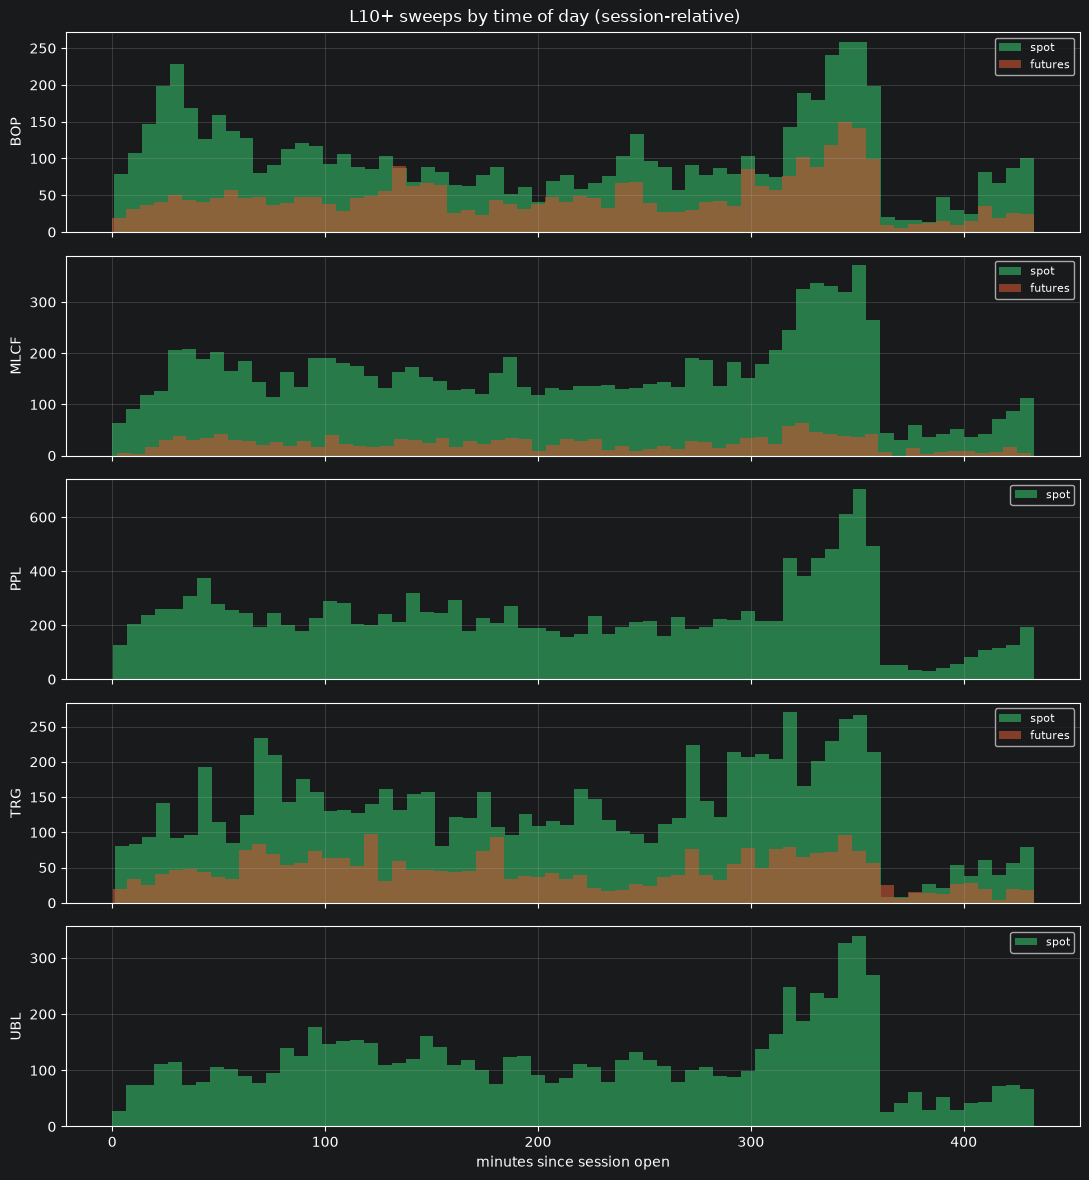

In [18]:
# just the L10+ sweeps
deep = sweeps[sweeps.is_L10plus].copy()

# --- time-of-day histogram (session-relative minutes) per market ---
# a figure with one panel per ticker
tickers = sorted(sweeps.ticker.unique())
# grid size
fig, axes = plt.subplots(len(tickers), 1, figsize=(11, 2.4 * len(tickers)),
                         sharex=True)
# ensure iterable
if len(tickers) == 1:
    axes = [axes]
# one panel per ticker
for ax, tk in zip(axes, tickers):
    # spot deep sweeps for this ticker
    ds = deep[(deep.ticker == tk) & (deep.market == "spot")]["sess_min"]
    # futures deep sweeps for this ticker
    df_ = deep[(deep.ticker == tk) & (deep.market == "futures")]["sess_min"]
    # spot histogram
    if len(ds):
        ax.hist(ds, bins=66, alpha=0.6, label="spot", color="#3b6")
    # futures histogram
    if len(df_):
        ax.hist(df_, bins=66, alpha=0.6, label="futures", color="#c53")
    # label
    ax.set_ylabel(tk)
    # grid + legend
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
# shared x label
axes[-1].set_xlabel("minutes since session open")
# title
fig.suptitle("L10+ sweeps by time of day (session-relative)")
# layout
fig.tight_layout()
# show
plt.show()


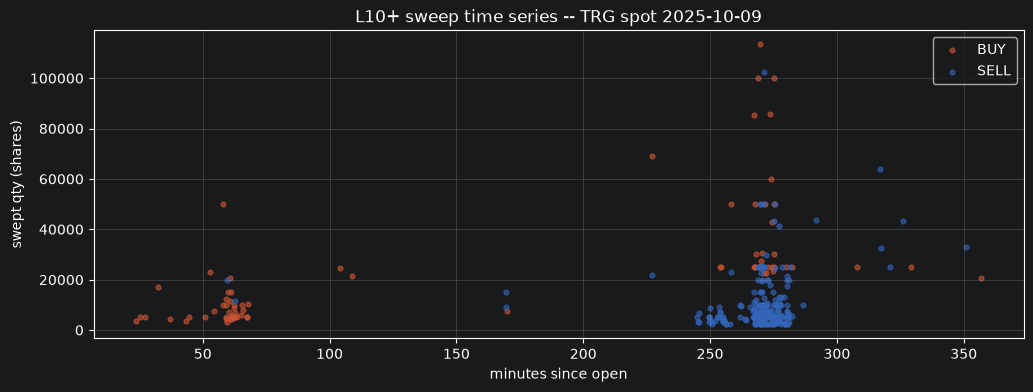

In [19]:
# --- time series: L10+ sweep events across one example day ---
# pick the most-active ticker-day for illustration
ex = (deep.groupby(["date", "ticker", "market"]).size()
      .sort_values(ascending=False))
# nothing?
if len(ex):
    # the busiest ticker-day
    (ex_date, ex_tk, ex_mkt) = ex.index[0]
    # that day's deep sweeps
    d1 = deep[(deep.date == ex_date) & (deep.ticker == ex_tk) &
              (deep.market == ex_mkt)]
    # a scatter of sweep size vs time
    fig, ax = plt.subplots(figsize=(12, 4))
    # color by side
    for side, col in (("BUY", "#c53"), ("SELL", "#36b")):
        # this side's sweeps
        sd = d1[d1.hit_side == side]
        # scatter (size ~ swept qty)
        ax.scatter(sd.sess_min, sd.swept_qty, s=12, alpha=0.6, label=side, color=col)
    # labels
    ax.set_xlabel("minutes since open"); ax.set_ylabel("swept qty (shares)")
    ax.set_title(f"L10+ sweep time series -- {ex_tk} {ex_mkt} {ex_date}")
    # grid + legend
    ax.grid(alpha=0.3); ax.legend()
    # show
    plt.show()


## 4. Q2 — Inter-arrival time between L10+ sweeps

How long between deep sweeps? Median sizes the dark period; heavy clustering (short gaps then long quiet) means the gate should key off the *cluster*, not each sweep.

In [20]:
# compute inter-arrival gaps (seconds) within each ticker-market-day
gaps = []
# group by a single trading session
for (dt, tk, mkt), g in deep.groupby(["date", "ticker", "market"]):
    # sorted sweep times (ms)
    ts = np.sort(g["t_ms"].to_numpy())
    # need >=2 to have a gap
    if len(ts) >= 2:
        # consecutive differences in seconds
        dif = np.diff(ts) / 1000.0
        # collect with tags
        for x in dif:
            gaps.append({"ticker": tk, "market": mkt, "gap_s": x})
# frame of gaps
gaps = pd.DataFrame(gaps)
# summary table: median / p25 / p75 inter-arrival per ticker+market
if len(gaps):
    # print the summary
    summ = gaps.groupby(["ticker", "market"])["gap_s"].agg(
        n="count", median="median",
        p25=lambda x: x.quantile(0.25), p75=lambda x: x.quantile(0.75))
    # show
    print(summ.to_string())


                    n   median      p25        p75
ticker market                                     
BOP    futures   2925   91.920  15.8500   560.1800
       spot      6432   54.525  10.4775   316.2725
MLCF   futures   1411  233.720  30.4800  1260.7300
       spot      9946   48.030   9.6925   227.4375
PPL    spot     15076   33.485   7.3700   151.3725
TRG    futures   2841   55.920   9.8900   403.4700
       spot      8379   29.460   5.2950   196.9100
UBL    spot      7427   60.790  11.5300   296.7000


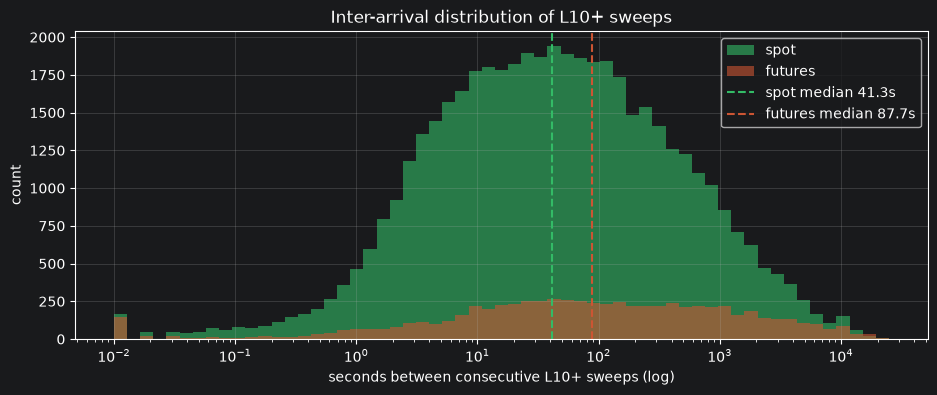

In [21]:
# histogram of inter-arrival gaps (log x, since heavy-tailed)
if len(gaps):
    # a figure
    fig, ax = plt.subplots(figsize=(11, 4))
    # spot gaps
    gs = gaps[gaps.market == "spot"]["gap_s"]
    # futures gaps
    gf = gaps[gaps.market == "futures"]["gap_s"]
    # log-spaced bins (gaps span ms to minutes)
    bins = np.logspace(np.log10(0.01), np.log10(max(gaps.gap_s.max(), 1)), 60)
    # spot histogram
    if len(gs):
        ax.hist(gs, bins=bins, alpha=0.6, label="spot", color="#3b6")
    # futures histogram
    if len(gf):
        ax.hist(gf, bins=bins, alpha=0.6, label="futures", color="#c53")
    # log x
    ax.set_xscale("log")
    # labels
    ax.set_xlabel("seconds between consecutive L10+ sweeps (log)")
    ax.set_ylabel("count")
    ax.set_title("Inter-arrival distribution of L10+ sweeps")
    # median markers
    for series, col, lab in ((gs, "#3b6", "spot"), (gf, "#c53", "futures")):
        # draw a median line if data
        if len(series):
            ax.axvline(series.median(), color=col, ls="--",
                       label=f"{lab} median {series.median():.1f}s")
    # grid + legend
    ax.grid(alpha=0.3); ax.legend()
    # show
    plt.show()


## 5. THE DECISIVE TEST — Conditional markout after L10+ sweeps

Signed by aggressor direction, so **positive = the mid kept moving the aggressor's
way = continuation = adverse to the resting quote that got hit = toxic.**

We compare markout after **L10+ sweeps** vs after **shallow (L1-L2) sweeps**. If deep
sweeps show materially worse (more positive) markout, the gate is justified — and the
horizon where the adverse move peaks sizes the dark period. If not, **stop here** —
going dark would forgo fills for no protection.

In [22]:
# depth class: deep (L10+) vs shallow (L1-L2)
sweeps["depth_class"] = np.where(sweeps.is_L10plus, "L10+",
                          np.where(sweeps.m2 <= 2, "L1-L2", "L3-L9"))
# mean signed markout (in PRICE units) by class + market, per horizon
mk_cols = ["mk5", "mk15", "mk30"]
# aggregate
cond = (sweeps.groupby(["market", "depth_class"])[mk_cols]
        .mean().reset_index())
# show the table
print("Mean SIGNED markout (price units; +ve = continuation = toxic):")
print(cond.to_string(index=False))


Mean SIGNED markout (price units; +ve = continuation = toxic):
 market depth_class       mk5      mk15      mk30
futures       L1-L2  0.000655  0.001044  0.001523
futures        L10+  0.001297 -0.002515  0.003542
futures       L3-L9 -0.000196  0.000127  0.000221
   spot       L1-L2  0.000066 -0.000145 -0.000437
   spot        L10+  0.000930  0.002204  0.004802
   spot       L3-L9 -0.000187 -0.000061  0.000384


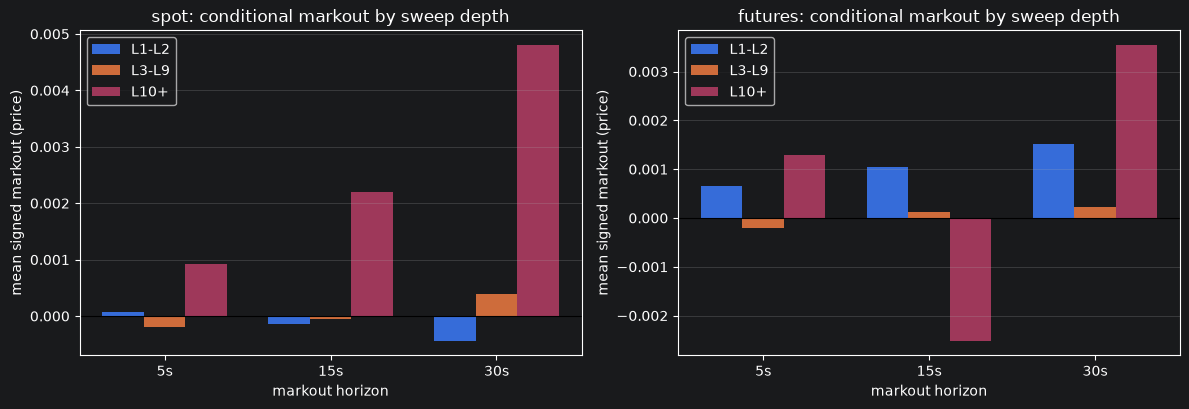

In [23]:
# bar chart: conditional markout by depth class, per horizon + market
# horizons as labels
hlabels = ["5s", "15s", "30s"]
# markets to show
mkts = [m for m in ["spot", "futures"] if m in sweeps.market.unique()]
# a panel per market
fig, axes = plt.subplots(1, len(mkts), figsize=(6 * len(mkts), 4.2), squeeze=False)
# fill each panel
for ax, mkt in zip(axes[0], mkts):
    # classes in a sensible order
    classes = ["L1-L2", "L3-L9", "L10+"]
    # x positions
    x = np.arange(len(hlabels)); w = 0.25
    # one bar group per class
    for k, cls in enumerate(classes):
        # the row for this market+class
        sub = cond[(cond.market == mkt) & (cond.depth_class == cls)]
        # skip if absent
        if len(sub) == 0:
            continue
        # the three horizon means
        vals = [sub[c].values[0] for c in mk_cols]
        # bars offset by class
        ax.bar(x + (k - 1) * w, vals, width=w, label=cls)
    # zero line
    ax.axhline(0, color="k", lw=0.8)
    # labels
    ax.set_xticks(x); ax.set_xticklabels(hlabels)
    ax.set_xlabel("markout horizon"); ax.set_ylabel("mean signed markout (price)")
    ax.set_title(f"{mkt}: conditional markout by sweep depth")
    # grid + legend
    ax.grid(axis="y", alpha=0.3); ax.legend()
# layout
fig.tight_layout()
# show
plt.show()


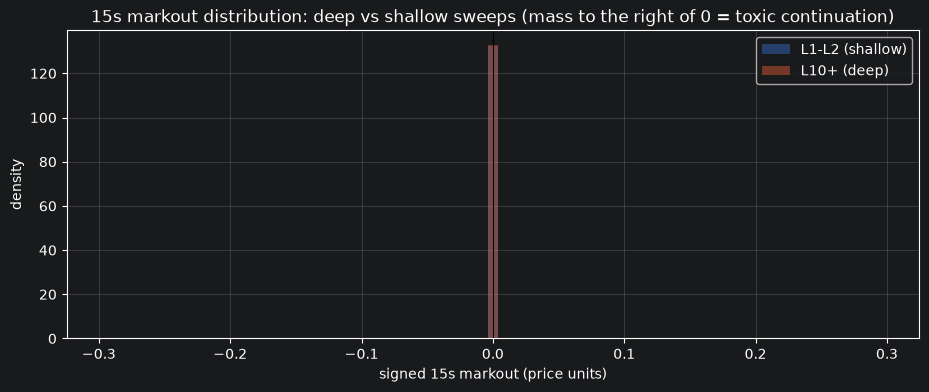

In [24]:
# also express markout in BPS (normalise by price level) for comparability
# approximate price level per ticker = median touch price proxy via mid moves is
# hard here; use the per-sweep swept notional? simpler: report bps vs a rough
# reference price = median of (mk magnitude scale). We instead show the DISTRIBUTION
# of mk15 for deep vs shallow to see if it's a mean effect or tail effect.
fig, ax = plt.subplots(figsize=(11, 4))
# deep 15s markout
dd = sweeps[sweeps.depth_class == "L10+"]["mk15"].dropna()
# shallow 15s markout
ss = sweeps[sweeps.depth_class == "L1-L2"]["mk15"].dropna()
# clip tails for a readable histogram
lim = np.nanpercentile(np.abs(pd.concat([dd, ss])), 99)
# bins
bins = np.linspace(-lim, lim, 80)
# shallow
ax.hist(ss, bins=bins, alpha=0.5, density=True, label="L1-L2 (shallow)", color="#36b")
# deep
ax.hist(dd, bins=bins, alpha=0.5, density=True, label="L10+ (deep)", color="#c53")
# zero line
ax.axvline(0, color="k", lw=0.8)
# labels
ax.set_xlabel("signed 15s markout (price units)"); ax.set_ylabel("density")
ax.set_title("15s markout distribution: deep vs shallow sweeps "
             "(mass to the right of 0 = toxic continuation)")
# grid + legend
ax.grid(alpha=0.3); ax.legend()
# show
plt.show()


## 6. Iceberg inference (signature, not detection)

No aggressor/order id exists, so we **infer** hidden liquidity two ways:

- **M2 − M1 gap.** M2 (book-diff on swept qty vs *visible* depth) says how many levels
  the quantity *should* have consumed; M1 (distinct trade prices) says how many prices
  it *actually* printed at. When a lot of quantity trades at **few prices**
  (M2 ≫ M1, especially M1 = 1), that's the fingerprint of an order refilling at one
  price — an iceberg.
- **swept / visible-touch ratio.** swept_qty far exceeding the visible touch depth is
  the same story from the size side.

Flagged as **inference**: separate reposting traders can mimic this. It is a signal, not proof.

In [25]:
# the hidden-liquidity gap per sweep
sweeps["hidden_gap"] = sweeps["m2"] - sweeps["m1"]
# a strong iceberg signal: many levels of qty consumed but printed at 1-2 prices
sweeps["iceberg_flag"] = (sweeps["m1"] <= 2) & (sweeps["m2"] >= 4)
# swept/visible ratio (how much bigger than the visible touch the sweep was)
sweeps["swept_over_touch"] = sweeps["swept_qty"] / sweeps["touch_qty"].replace(0, np.nan)
# summary per ticker + market
ice = (sweeps.groupby(["ticker", "market"])
       .agg(sweeps_n=("m1", "count"),
            iceberg_share_pct=("iceberg_flag", lambda x: 100 * x.mean()),
            median_hidden_gap=("hidden_gap", "median"),
            median_swept_over_touch=("swept_over_touch", "median"))
       .reset_index())
# show
print("Iceberg inference by ticker (higher share / gap = more hidden liquidity):")
print(ice.to_string(index=False))


Iceberg inference by ticker (higher share / gap = more hidden liquidity):
ticker  market  sweeps_n  iceberg_share_pct  median_hidden_gap  median_swept_over_touch
   BOP futures    468686           7.820161                0.0                 0.500000
   BOP    spot   1338626           5.061832                0.0                 0.219298
  MLCF futures    212985           7.523535                0.0                 0.666667
  MLCF    spot    790894           7.276449                0.0                 0.288517
   PPL    spot    901760           7.807842                0.0                 0.221774
   TRG futures    279566           7.831782                0.0                 0.750000
   TRG    spot    544982          10.056662                0.0                 0.605327
   UBL    spot    429303           6.326534                0.0                 0.150000


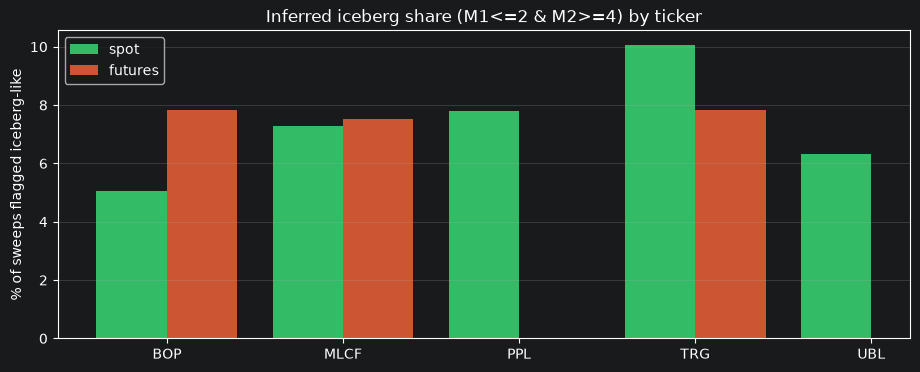

In [26]:
# bar chart: iceberg share per ticker, spot vs futures
# tickers present
tks = sorted(sweeps.ticker.unique())
# x positions
x = np.arange(len(tks)); w = 0.4
# a figure
fig, ax = plt.subplots(figsize=(11, 4))
# spot values
sv = [ice[(ice.ticker == tk) & (ice.market == "spot")]["iceberg_share_pct"].values
      for tk in tks]
# futures values
fv = [ice[(ice.ticker == tk) & (ice.market == "futures")]["iceberg_share_pct"].values
      for tk in tks]
# flatten (nan where absent)
sv = [v[0] if len(v) else np.nan for v in sv]
fv = [v[0] if len(v) else np.nan for v in fv]
# spot bars
ax.bar(x - w/2, sv, width=w, label="spot", color="#3b6")
# futures bars
ax.bar(x + w/2, fv, width=w, label="futures", color="#c53")
# labels
ax.set_xticks(x); ax.set_xticklabels(tks)
ax.set_ylabel("% of sweeps flagged iceberg-like")
ax.set_title("Inferred iceberg share (M1<=2 & M2>=4) by ticker")
# grid + legend
ax.grid(axis="y", alpha=0.3); ax.legend()
# show
plt.show()


## 7. Verdict — is the gate worth building?

Read the **conditional markout** chart (section 5):

- **If L10+ markout is clearly positive and larger than shallow-sweep markout**, deep
  sweeps predict continuation → resting quotes get run over → **the gate is justified.**
  Size the dark period at the horizon where the adverse move peaks (5 / 15 / 30 s), and
  cross-check against the **inter-arrival median** (section 4): the dark period should be
  shorter than the typical gap or you forgo too many fills.
- **If L10+ markout is ~0 or no worse than shallow**, deep sweeps are *not* toxic here →
  **do not build the gate**; it would cost fills for no protection.

The **time-of-day** chart (section 3) tells you whether to make the gate *scheduled*
(if sweeps bunch at open/close) or purely *reactive*.

The **iceberg** section is diagnostic context: high inferred-iceberg share means the
visible book understates true liquidity, which matters for quote sizing and for how you
interpret your own fills.